In [ ]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [ ]:
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=200)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [ ]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [ ]:
from tensorflow import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,)))
model.add(keras.layers.Embedding(200,16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1,activation='sigmoid')) # 긍정/부정 이진 분류에는 sigmoid 사용

In [32]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_simplernn_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=128, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5153 - loss: 0.6929 - val_accuracy: 0.5596 - val_loss: 0.6923
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5522 - loss: 0.6921 - val_accuracy: 0.5780 - val_loss: 0.6915
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5702 - loss: 0.6911 - val_accuracy: 0.5960 - val_loss: 0.6902
Epoch 4/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5828 - loss: 0.6900

KeyboardInterrupt: 

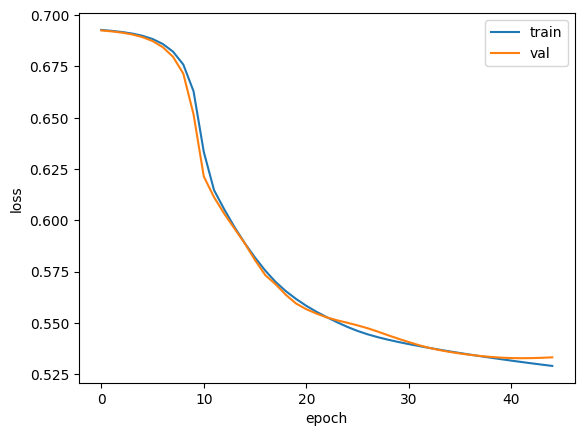

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [ ]:
from tensorflow import keras

model2 = keras.Sequential()
model2.add(keras.layers.Input(shape=(100,)))
model2.add(keras.layers.Embedding(200,16))
model2.add(keras.layers.LSTM(8, dropout=0.3))  # dropout으로 네트워크? 줄여서 오히려 더 나빠질 수 있음
model2.add(keras.layers.Dense(1, activation='sigmoid')) # 긍정/부정 이진 분류에는 sigmoid 사용


In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_Dropout_model2.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model2.fit(train_seq, train_target, epochs=100, batch_size=128, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.4964 - val_loss: 0.6931
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5156 - loss: 0.6927 - val_accuracy: 0.5250 - val_loss: 0.6925
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5404 - loss: 0.6922 - val_accuracy: 0.5502 - val_loss: 0.6919
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5519 - loss: 0.6915 - val_accuracy: 0.5670 - val_loss: 0.6911
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5667 - loss: 0.6905 - val_accuracy: 0.5836 - val_loss: 0.6899
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5763 - loss: 0.6892 - val_accuracy: 0.5976 - val_loss: 0.6883
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5888 - loss: 0.6871 - val_accuracy: 0.6054 - val_loss: 0.6859
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5994 - loss: 0.6842 - 

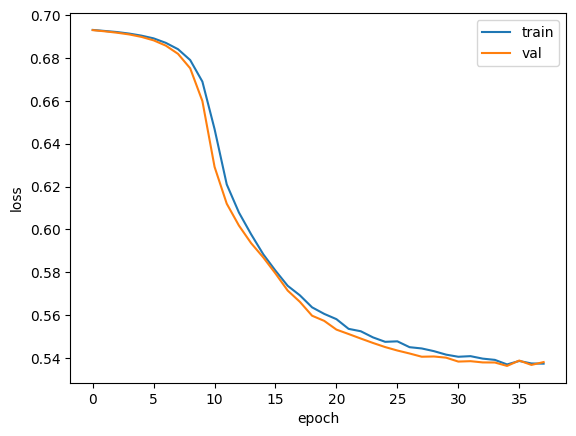

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [ ]:
from tensorflow import keras

model3 = keras.Sequential()
model3.add(keras.layers.Input(shape=(100,)))
model3.add(keras.layers.Embedding(200,16))
model3.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))  # dropout으로 네트워크? 줄여서 오히려 더 나빠질 수 있음
model3.add(keras.layers.LSTM(8, dropout=0.3))
model3.add(keras.layers.Dense(1, activation='sigmoid')) # 긍정/부정 이진 분류에는 sigmoid 사용


In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model3.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_2LSTM_model3.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model3.fit(train_seq, train_target, epochs=100, batch_size=128, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.4940 - val_loss: 0.6932
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5098 - loss: 0.6930 - val_accuracy: 0.5050 - val_loss: 0.6930
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5182 - loss: 0.6928 - val_accuracy: 0.5158 - val_loss: 0.6928
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5342 - loss: 0.6925 - val_accuracy: 0.5508 - val_loss: 0.6924
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5487 - loss: 0.6919 - val_accuracy: 0.5926 - val_loss: 0.6916
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5646 - loss: 0.6908 - val_accuracy: 0.6248 - val_loss: 0.6897
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5709 - loss: 0.6880 - val_accuracy: 0.6384 - val_loss: 0.6851
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5945 - loss: 0.6791 - 

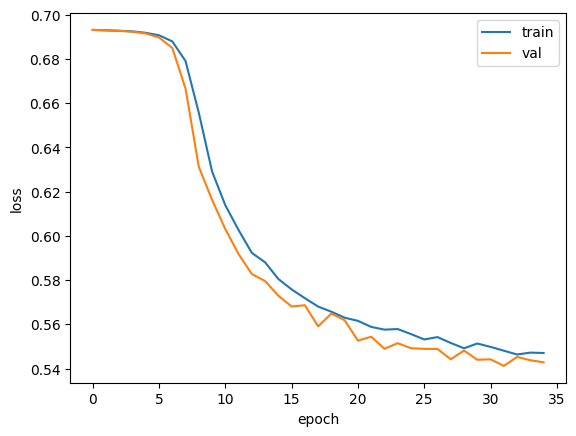

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [1]:
def seq2dataset(seq,window,horizon):
    X=[]; Y=[]
    for i in range(len(seq)-(window+horizon)+1):
        x=seq[i:(i+window)]
        y=(seq[i+window+horizon-1])
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

In [2]:
ls

 C ����̺��� �������� �̸��� �����ϴ�.
 ���� �Ϸ� ��ȣ: EC36-8D2C

 c:\Users\USER\Desktop\SeSAC_DE\sesac_workspace\251212 ���͸�

2025-12-12  ���� 11:14    <DIR>          .
2025-12-12  ���� 09:11    <DIR>          ..
2025-12-12  ���� 01:43           306,435 1212.ipynb
2025-12-12  ���� 11:09            69,542 best_2LSTM_model3.keras
2025-12-12  ���� 11:05            57,724 best_Dropout_model2.keras
2025-12-12  ���� 01:42            57,722 best_simplernn_model.keras
2025-12-12  ���� 11:12            29,447 BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv
               5�� ����             520,870 ����Ʈ
               2�� ���͸�  396,730,961,920 ����Ʈ ����


In [3]:
# 폴더에 넣은 csv 파일 읽어들이기
import pandas as pd
data = pd.read_csv('C:/Users/USER/Desktop/SeSAC_DE/sesac_workspace/251212/BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv')

In [4]:
data.head()

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2019-02-28,3772.936335,3796.637284,3824.165879,3666.524016
1,BTC,2019-03-01,3799.678543,3773.441461,3879.231185,3753.800022
2,BTC,2019-03-02,3811.611979,3799.367026,3840.044823,3788.918498
3,BTC,2019-03-03,3804.419170,3806.691513,3819.194356,3759.409216
4,BTC,2019-03-04,3782.664101,3807.845756,3818.695481,3766.242048


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Currency             365 non-null    object 
 1   Date                 365 non-null    object 
 2   Closing Price (USD)  365 non-null    float64
 3   24h Open (USD)       365 non-null    float64
 4   24h High (USD)       365 non-null    float64
 5   24h Low (USD)        365 non-null    float64
dtypes: float64(4), object(2)
memory usage: 17.2+ KB


In [6]:
data['Closing Price (USD)'].shape

(365,)

w = 7, h = 1

In [7]:
seq = data[['Closing Price (USD)']].to_numpy()  # 핵심 : 대괄호 두개
seq.shape

(365, 1)

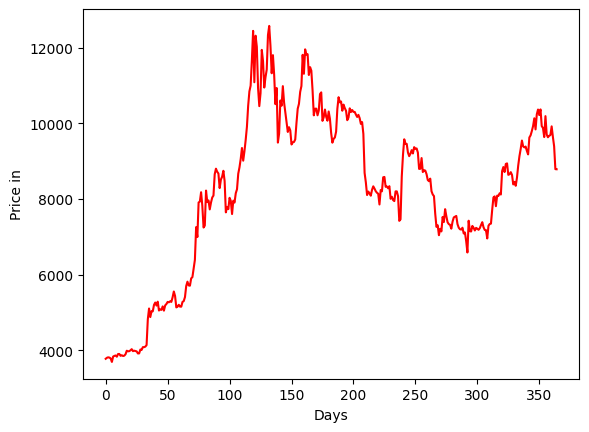

In [8]:
import matplotlib.pyplot as plt

plt.plot(seq, color = 'red')
plt.xlabel('Days')
plt.ylabel('Price in')
plt.show()

In [9]:
import numpy as np

w = 7
h = 1

X, Y = seq2dataset(seq, w, h)

In [10]:
X.shape, Y.shape

((358, 7, 1), (358, 1))

In [11]:
print(X[0], Y[0])
print(X[1])

[[3772.93633533]
 [3799.67854295]
 [3811.61197937]
 [3804.41917011]
 [3782.66410112]
 [3689.86289319]
 [3832.08088473]] [3848.95636968]
[[3799.67854295]
 [3811.61197937]
 [3804.41917011]
 [3782.66410112]
 [3689.86289319]
 [3832.08088473]
 [3848.95636968]]


In [12]:
split = int(len(X)*0.7)

In [13]:
split

250

In [14]:
x_train = X[0:split]
y_train = Y[:split]

x_test = X[split:]
y_test = Y[split:]

In [15]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((250, 7, 1), (250, 1), (108, 7, 1), (108, 1))

In [16]:
x_train[0].shape

(7, 1)

LSTM은 임베딩층 필요 없음(언어가 아니기 때문)

*모델 만들기*
input_shape = x_train
LSTM : 노드수 128
활성화 함수 : relu
Dense(1)
loss = 'mae'.adam
metrics = ['mae']
epochs=200, batch_Size=1,
validation_data = (x_test, y_test)


In [17]:
from tensorflow import keras

# 모델 생성
model4 = keras.Sequential()
# 입력층(timesteps, features)
model4.add(keras.layers.Input(shape=x_train[0].shape)) # 모델의 입력 형태 정의
# LSTM층
model4.add(keras.layers.LSTM(128, activation='relu')) # 128개 노드, 시계열 전체를 읽고 마지막 시점 정보만 출력, 출력 shape = (128,)
# 출력층
model4.add(keras.layers.Dense(1)) # 출력 노드 1개, 연속값 예측(회귀 문제)
# 컴파일
model4.compile(optimizer='adam', loss='mae', metrics=['mae']) # Adam: 가중치 업데이터 방식, MAE: 실제값과 예측값의 평균 절대 오차
# 학습
history = model4.fit(x_train, y_train, epochs=200, batch_size=1, validation_data = (x_test, y_test))

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1761.4480 - mae: 1761.4480 - val_loss: 413.6071 - val_mae: 413.6071
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 516.4410 - mae: 516.4410 - val_loss: 385.3551 - val_mae: 385.3551
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 485.2919 - mae: 485.2919 - val_loss: 341.6793 - val_mae: 341.6793
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 485.4802 - mae: 485.4802 - val_loss: 502.6659 - val_mae: 502.6659
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 528.0578 - mae: 528.0578 - val_loss: 409.5365 - val_mae: 409.5365
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 500.7545 - mae: 500.7545 - val_loss: 392.6471 - val_mae: 392.6471
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 465.1898 - mae: 465.1898 - val_loss: 288.2270 - val_mae: 288.2270
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 559.7706 - mae: 559.7706 - val_loss: 295.0364 - 

활성화 함수 -> 의사결정 하는 층에 넣음  
분류에서는 Dense(이진분류), 시계열 표현을 바꾸고 싶을때는 LSTM에 둠  
LSTM에 activation 넣으면 => LSTM이 만들어내는 '은닉상태(h)'를 relu를 거쳐서 출력하겠다  

LSTM(128, activation='relu')
↓
Dense(1)

=> 시계열을 보고 relu 기반 특징을 128차원으로 만들고 그 결과를 그대로 숫자로 출력하겠다

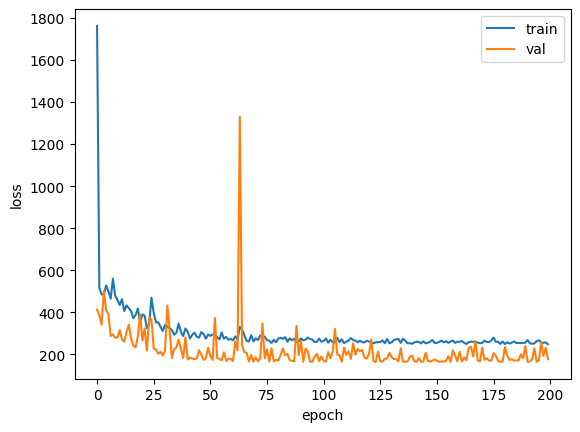

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

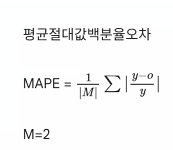

B) y= [120,200], pred = [100,210], MAE=(20+10)/2 = 15

평균절대값백분율오차 관련,, 지피티한테 물어봐

MAPE 쓰는 이유
-> 스케일링을 한거다..?

In [19]:
((12-10)/12 + (21-20)/20)/2

0.10833333333333334

In [20]:
((120-100)/120 + (210-200)/200)/2

0.10833333333333334

In [21]:
ev = model4.evaluate(x_test, y_test)
ev
# 출력 결과에서 loss가 낮으면 좋은거임

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 177.6740 - mae: 177.6740  


[177.6739959716797, 177.6739959716797]

In [22]:
pred = model4.predict(x_test) # 예측값 구하기

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [23]:
sum(abs(y_test-pred)/y_test)/len(x_test)

array([0.02123489])

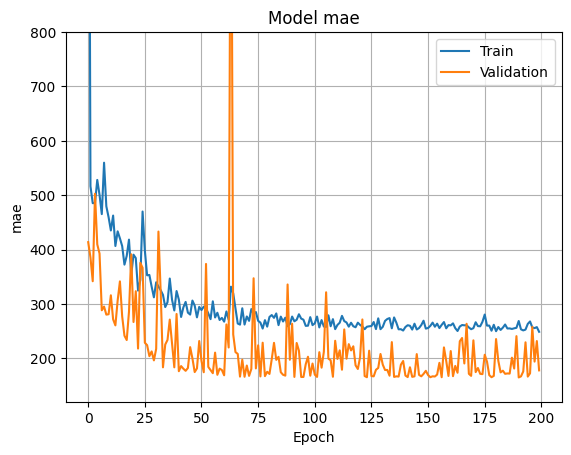

In [25]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model mae')
plt.ylabel('mae')
plt.xlabel('Epoch')
plt.ylim([120,800])
plt.legend(['Train', 'Validation'],loc='best')
plt.grid()
plt.show()

어텐션으로만 이뤄진게 트랜스포머 ..?

### 트랜스포머(Transformer)
-> RNN, CNN 없이 어텐션(Attention)만으로 시퀀스를 처리하는 모델  
-> 모든 단어를 한번에 처리, 긴 문장도 잘 이해함, GPU 병렬 처리 가능  

<기존 모델들>  
- RNN / LSTM : 순서대로 처리(느림, 장기 의존성 문제)  
- CNN : 국소 패턴은 잘 잡지만 긴 문맥은 한계  

Transformer는 이 둘을 전부 제거하고, Self-Attention만으로 문맥을 학습  

<Transformer 한 블록은 이렇게 생김>  
입력  
 ↓  
Self-Attention  
 ↓  
FFN  
 ↓  
출력  
-> 이걸 여러 층 쌓은게 트랜스포머  

### 어덴션(Attention)
-> 지금 이 단어(or 시점)을 이해할 때, 다른 것들 중에서 무엇을 얼마나 중요하게 볼지 정하는 방법

##### 필요 이유
문장 끝에있는 단어가 문장 앞쪽의 단어를 다시 집중(attend)해서 봐야 함  
-> 필요할 때 다시 찾아봄. 모든 단어를 펼쳐놓고 지금 필요한 단어에 가중치(중요도)를 줌  
-> 중요한 정보를 더 집중해서 보는 가중 평균 방식  

#### Self-Attention
-> 문장 안의 단어들이 서로를 참고(attend)하는 어텐션

Attention 층의 목적 -> 맥락 벡터(Context vector) 만들기  
각 단계별로 중요한 은닉상태에 점수를 더 줌?


In [40]:
N, T, H = 3, 4, 5 # N : 샘플수, T : timestamp, H : 단어표현(벡터표현)

In [41]:
hs = np.random.randn(N, T, H) # 인코더의 모든 은닉 상태
hs

array([[[ 0.53466674, -0.96031863, -0.64911566, -1.21867996,
         -0.36351464],
        [-0.61175672,  0.0297606 ,  0.18049769,  2.20823612,
          1.49749816],
        [-0.17741855,  1.24349444,  0.02848885,  0.30518618,
          0.82622108],
        [-1.30231127, -0.24352746, -0.43562754,  1.65544407,
          1.24997392]],

       [[ 0.44939274, -0.53508508,  2.9403505 , -1.25573855,
         -0.08747431],
        [-0.40098213, -0.24195852,  0.46085361,  0.77287003,
         -0.42396546],
        [-0.4588395 , -1.63830618,  0.51139732,  0.71684466,
         -1.23527974],
        [-0.23829293,  0.99863957, -0.18519161, -0.54789226,
          0.66242047]],

       [[-1.50809767, -1.44841386, -1.50399734,  0.56035495,
          0.17394152],
        [ 0.86540941, -0.31297911,  0.40460351,  1.07231419,
          0.55969218],
        [-0.02861906,  0.01308919, -0.45629152,  0.47713903,
         -0.45993428],
        [ 1.41920207,  0.92613875,  0.67059747, -0.69786992,
         -0

In [42]:
h = np.random.randn(N,H) # 디코더의 은닉 상태
h

array([[ 1.17874768,  1.05449035, -0.99987107,  1.80395967,  0.14525178],
       [-0.60337791, -1.07159729,  0.26236779,  2.26036651,  0.76416526],
       [-0.31803438, -0.60847197,  0.85067656, -0.4696526 , -0.8358324 ]])

In [43]:
h.reshape(N, 1, H)

array([[[ 1.17874768,  1.05449035, -0.99987107,  1.80395967,
          0.14525178]],

       [[-0.60337791, -1.07159729,  0.26236779,  2.26036651,
          0.76416526]],

       [[-0.31803438, -0.60847197,  0.85067656, -0.4696526 ,
         -0.8358324 ]]])

In [44]:
hr = h.reshape(N, 1, H).repeat(T, axis=1)

In [45]:
hr

array([[[ 1.17874768,  1.05449035, -0.99987107,  1.80395967,
          0.14525178],
        [ 1.17874768,  1.05449035, -0.99987107,  1.80395967,
          0.14525178],
        [ 1.17874768,  1.05449035, -0.99987107,  1.80395967,
          0.14525178],
        [ 1.17874768,  1.05449035, -0.99987107,  1.80395967,
          0.14525178]],

       [[-0.60337791, -1.07159729,  0.26236779,  2.26036651,
          0.76416526],
        [-0.60337791, -1.07159729,  0.26236779,  2.26036651,
          0.76416526],
        [-0.60337791, -1.07159729,  0.26236779,  2.26036651,
          0.76416526],
        [-0.60337791, -1.07159729,  0.26236779,  2.26036651,
          0.76416526]],

       [[-0.31803438, -0.60847197,  0.85067656, -0.4696526 ,
         -0.8358324 ],
        [-0.31803438, -0.60847197,  0.85067656, -0.4696526 ,
         -0.8358324 ],
        [-0.31803438, -0.60847197,  0.85067656, -0.4696526 ,
         -0.8358324 ],
        [-0.31803438, -0.60847197,  0.85067656, -0.4696526 ,
         -0

Attention Score (pdf p.21) 부분을 코딩한거

In [46]:
import numpy as np

# 데이터 준비 (병호 님이 작성하신 코드)
N, T, H = 3, 5, 4
hs = np.random.randn(N, T, H)
h = np.random.rand(N, H)
hr = h.reshape(N, 1, H).repeat(T, axis=1)

# 1. 곱하기 (Element-wise Product)
# 아직은 [점수1, 점수2, 점수3, 점수4] 이렇게 흩어져 있음
t1 = hs * hr  # 모양: (3, 5, 4)

# 2. 더하기 (Sum with axis=2) -> 이게 핵심!
# 흩어진 4개 점수를 합쳐서 '그 날의 최종 점수' 1개로 만듦
score = np.sum(t1, axis=2) 

print(score.shape) 
# 결과: (3, 5) 
# 해석: 공장 3곳(N)에서, 5일치(T) 각각에 대한 점수가 나옴. (H는 더해서 사라짐)

(3, 5)


In [47]:
t = hs * hr
s = np.sum(t, axis = 2)

In [49]:
t.shape, s.shape

((3, 5, 4), (3, 5))

In [50]:
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x

class Softmax:
    def init(self):
        self.params, self.grads = [], []
        self.out = None

    def forward(self, x):
        self.out = softmax(x)
        return self.out

    def backward(self, dout):
        dx = self.out * dout
        sumdx = np.sum(dx, axis=1, keepdims=True)
        dx -= self.out * sumdx
        return dx

In [51]:
a = Softmax().forward(s)

In [52]:
a.sum(axis=1)

array([1., 1., 1.])

In [53]:
a

array([[0.03156752, 0.38219443, 0.085103  , 0.14275896, 0.35837609],
       [0.06973781, 0.32137888, 0.23686548, 0.02942748, 0.34259035],
       [0.04979502, 0.41686221, 0.26975823, 0.14696018, 0.11662435]])

In [54]:
a.shape

(3, 5)

In [58]:
ar = a.reshape(N, T, 1).repeat(H, axis= 2)
ar

array([[[0.03156752, 0.03156752, 0.03156752, 0.03156752],
        [0.38219443, 0.38219443, 0.38219443, 0.38219443],
        [0.085103  , 0.085103  , 0.085103  , 0.085103  ],
        [0.14275896, 0.14275896, 0.14275896, 0.14275896],
        [0.35837609, 0.35837609, 0.35837609, 0.35837609]],

       [[0.06973781, 0.06973781, 0.06973781, 0.06973781],
        [0.32137888, 0.32137888, 0.32137888, 0.32137888],
        [0.23686548, 0.23686548, 0.23686548, 0.23686548],
        [0.02942748, 0.02942748, 0.02942748, 0.02942748],
        [0.34259035, 0.34259035, 0.34259035, 0.34259035]],

       [[0.04979502, 0.04979502, 0.04979502, 0.04979502],
        [0.41686221, 0.41686221, 0.41686221, 0.41686221],
        [0.26975823, 0.26975823, 0.26975823, 0.26975823],
        [0.14696018, 0.14696018, 0.14696018, 0.14696018],
        [0.11662435, 0.11662435, 0.11662435, 0.11662435]]])

In [59]:
ar.shape, hs.shape

((3, 5, 4), (3, 5, 4))

In [64]:
t = hs*ar

In [65]:
t.shape

(3, 5, 4)

In [66]:
t

array([[[-1.43183848e-02, -2.03730086e-03, -1.69923360e-03,
         -3.33322674e-02],
        [-6.34281867e-02,  4.43720042e-01,  9.72823329e-02,
         -4.95077695e-02],
        [ 8.88451751e-02,  3.67532535e-02, -8.92354683e-02,
         -1.16865137e-01],
        [-1.05049089e-01, -2.59777151e-01,  2.91475293e-01,
          1.90375986e-01],
        [-5.70424387e-01,  1.66463930e-01,  1.01555125e+00,
          9.14578173e-02]],

       [[-3.09654456e-02, -2.21649935e-02,  4.78484173e-04,
         -5.67168665e-02],
        [ 2.65104289e-02, -6.91742613e-02,  8.01558153e-01,
         -2.77965249e-01],
        [ 2.91024143e-01,  1.67909034e-01, -1.16227759e-01,
         -5.35773636e-02],
        [-2.89715420e-03, -5.44655112e-02, -7.72467967e-03,
         -1.62347228e-02],
        [-4.06127552e-01,  3.27160778e-01,  5.43010253e-01,
         -2.80876590e-01]],

       [[-9.35376084e-02, -2.31185500e-02,  1.98761278e-03,
          4.34683359e-02],
        [ 4.93480334e-01, -1.59303981e-

In [61]:
c = np.sum(t, axis=1)

In [62]:
c.shape

(3, 4)

In [63]:
c

array([[-1.805841  ,  0.1678126 ,  2.52175319, -0.87929637],
       [-0.07551985, -0.47324193,  1.89123248, -2.94201683],
       [-0.17574485, -2.16475495,  4.23731165,  0.70359199]])